# Spatial Autocorrelation — Global and Local

**Companion to deck `05-spatial-dependence` (Part 2 — Measurements, Areal data).**

*Exploratory Spatial Data Analysis* (ESDA) asks two questions of a map. **Global**
measures give a single number — *does* the variable cluster in space? **Local**
measures (LISA) then say *where* that clustering happens. This notebook works both
on the same dataset the slides use, so the printed numbers match the deck.

Worked example: **median house value across San Diego census tracts** — the
`knaaptime` ESDA workflow (Rey, Arribas-Bel & Wolf, *Geographic Data Science with
Python*; Anselin 1995, 1996).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from libpysal.graph import Graph
from esda import Moran, Moran_Local, fdr
from splot.esda import plot_moran, moran_scatterplot, lisa_cluster

%config InlineBackend.figure_format = "retina"

# One fixed seed makes every permutation-based number below reproducible.
SEED = 42

## 1. Load the data

628 census tracts for San Diego, already in a **projected CRS** (EPSG:3857, metres),
which is what contiguity and distance rules need. We drop the handful of tracts with
a missing `median_house_value`.

In [2]:
tracts = gpd.read_file("data/sandiego/sandiego_tracts.gpkg")
tracts = tracts.dropna(subset=["median_house_value"]).reset_index(drop=True)

print(f"{len(tracts)} tracts, CRS EPSG:{tracts.crs.to_epsg()}")
tracts[["GEOID", "median_house_value"]].head()

628 tracts, CRS EPSG:3857


,GEOID,median_house_value
0,06073018300,732900.000000
1,06073018601,473800.000000
2,06073017601,930600.000000
3,06073019301,478500.000000
4,06073018700,515570.896382


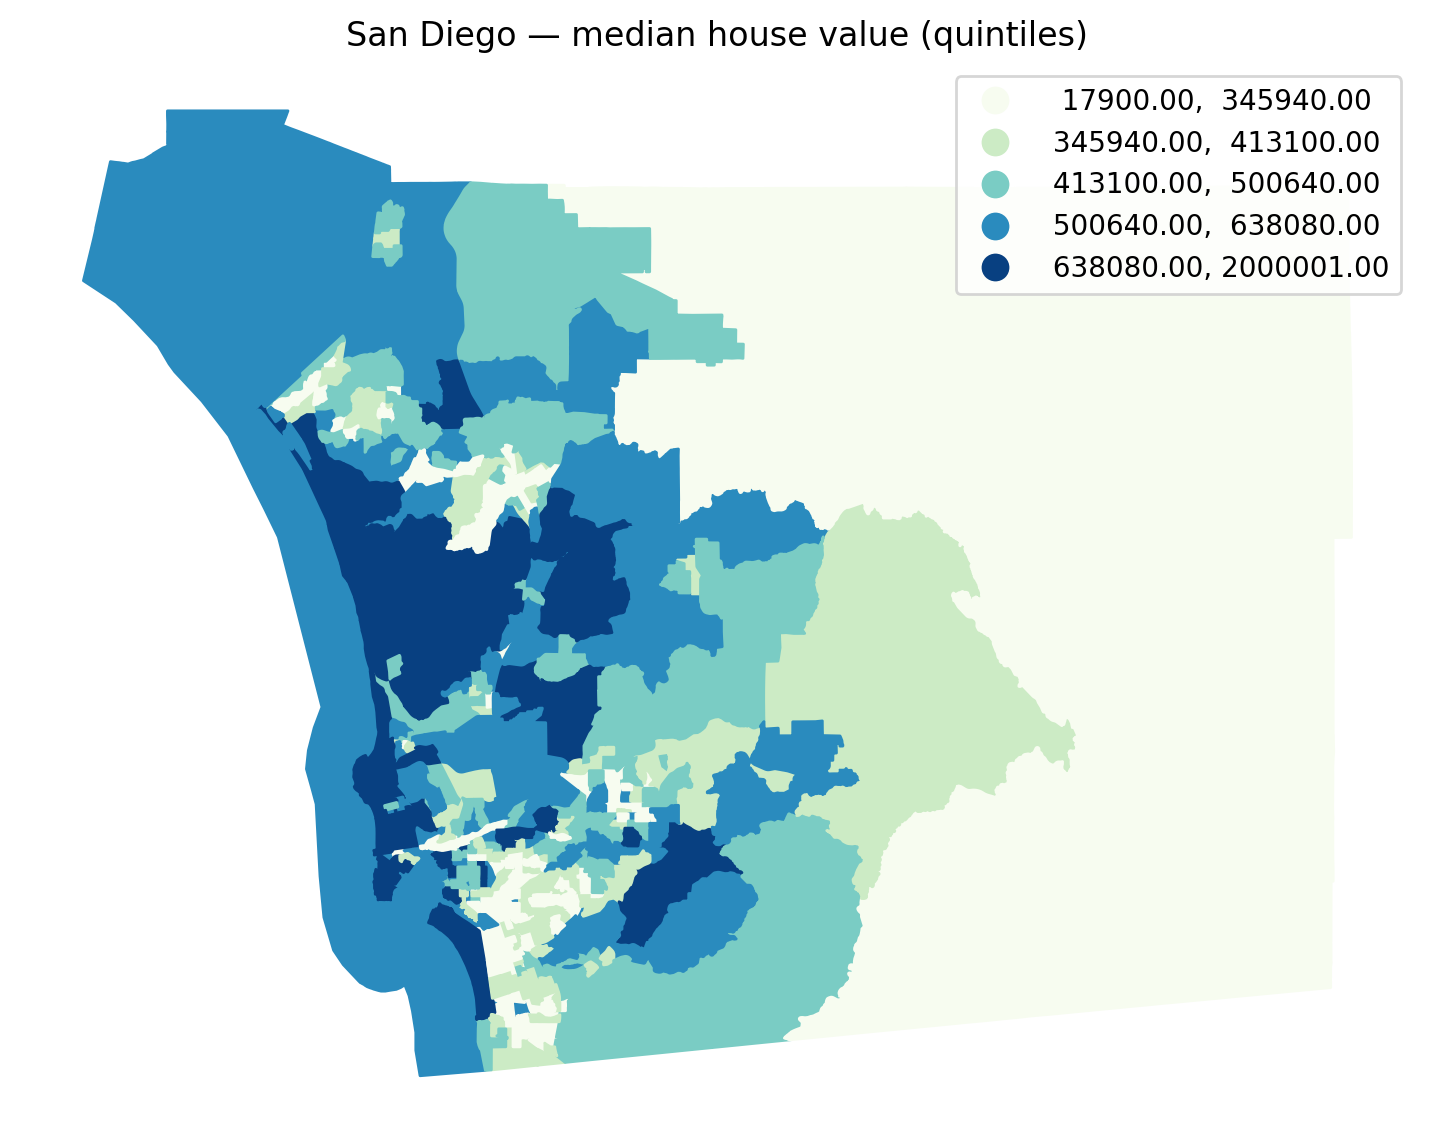

In [3]:
f, ax = plt.subplots(figsize=(9, 9))
tracts.plot(column="median_house_value", scheme="quantiles", k=5,
            cmap="GnBu", edgecolor="face", legend=True, ax=ax)
ax.set_title("San Diego — median house value (quintiles)")
ax.set_axis_off()
plt.show()

Our eye is drawn to dark clusters (expensive tracts) along the coast and pale
low-value pockets inland. But eyes over-detect pattern in irregular polygons —
*spatial autocorrelation* replaces that hunch with a test.

## 2. Spatial similarity — the weights graph

Spatial autocorrelation combines two kinds of similarity: **spatial** (who is a
neighbour) and **attribute** (are their values alike). The graph `W` formalises the
first. We use **Queen contiguity** (share a border *or* a vertex) and
**row-standardise** so each tract's neighbour weights sum to 1 — the standard choice
for interpreting a spatial lag as a neighbour average.

In [4]:
g = Graph.build_contiguity(tracts, rook=False)   # Queen contiguity
print("isolates:", len(g.isolates), " components:", g.n_components)

# Bridge the modern Graph to the legacy W that esda/splot still consume.
w = g.transform("r").to_W()

isolates: 0  components: 1


No isolates and a single connected component — every tract has neighbours, so
no observation is silently dropped from the statistics.

## 3. Attribute similarity — the spatial lag

For tract $i$ the **spatial lag** is the neighbour average
$$Wy_i = \sum_j w_{ij}\, y_j.$$
Mapping $Wy$ beside $y$ is the first visual diagnostic: if the lag map echoes the raw
map, neighbours mirror each other — the signature of positive autocorrelation.

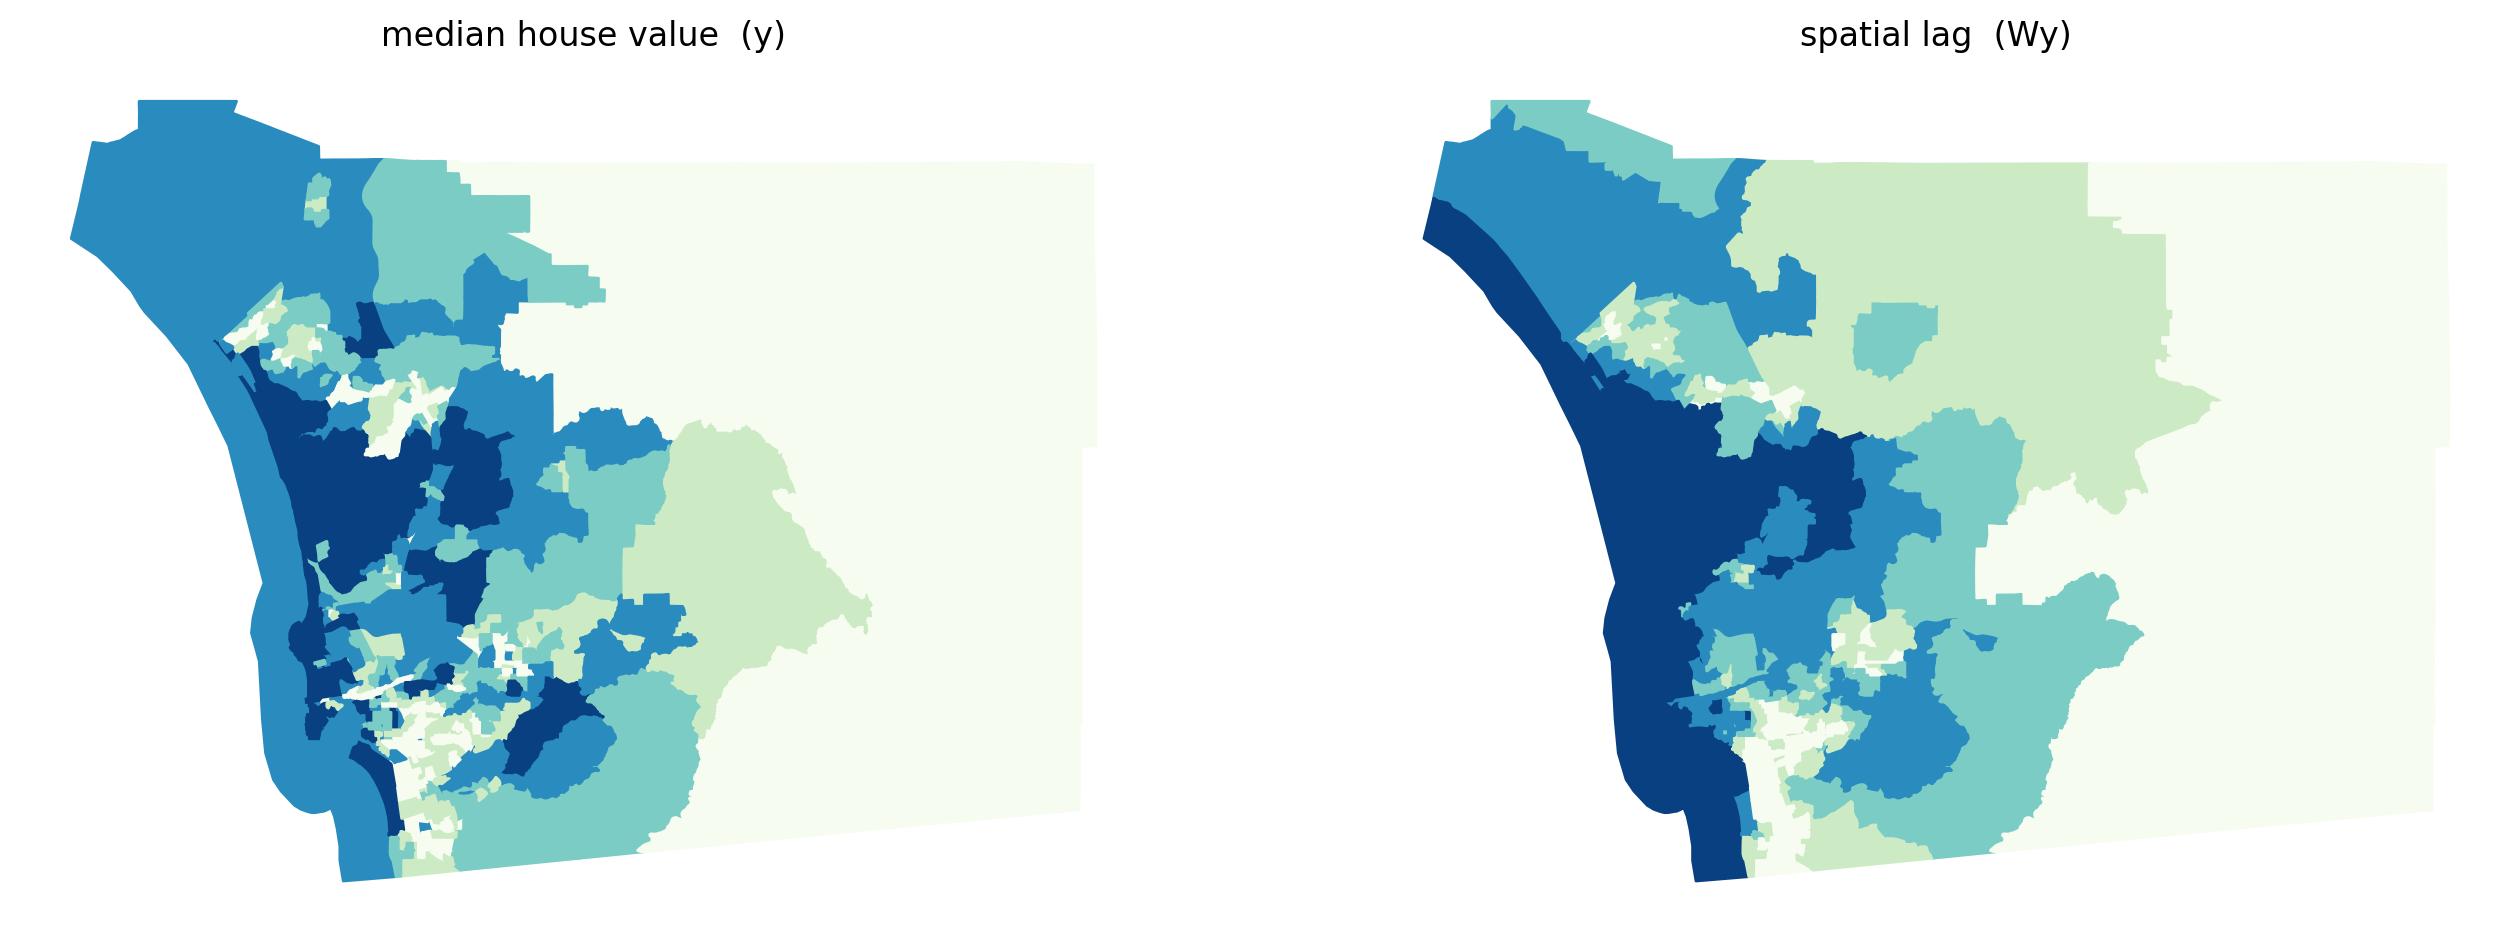

In [5]:
tracts["w_mhv"] = w.sparse @ tracts["median_house_value"].values

f, ax = plt.subplots(1, 2, figsize=(16, 7))
tracts.plot(column="median_house_value", scheme="quantiles", k=5, cmap="GnBu",
            edgecolor="face", ax=ax[0])
ax[0].set_title("median house value  (y)")
tracts.plot(column="w_mhv", scheme="quantiles", k=5, cmap="GnBu",
            edgecolor="face", ax=ax[1])
ax[1].set_title("spatial lag  (Wy)")
for a in ax:
    a.set_axis_off()
plt.show()

The lag map is a local smoother: it enhances the impression of value similarity
in space, exactly where the raw map already hinted at clustering.

**Lesson —** map $Wy$, not just $y$: when the lag map echoes the raw map, neighbours
mirror each other — the visual signature of positive autocorrelation.

## 4. Global Moran's I

Moran's I is the spatial analogue of a correlation coefficient: it cross-multiplies
each tract's deviation from the mean with its neighbours' deviations, normalised by
the total connection weight $S_0=\sum_i\sum_j w_{ij}$:
$$I = \frac{n}{S_0}\,\frac{\sum_i\sum_j w_{ij}(y_i-\bar y)(y_j-\bar y)}{\sum_i (y_i-\bar y)^2}.$$
This is the deck's worked example, executed.

In [6]:
y = tracts["median_house_value"]
w = Graph.build_contiguity(tracts, rook=False).transform("r").to_W()

np.random.seed(SEED)
mi = Moran(y, w, permutations=999)
print(round(mi.I, 3), mi.p_sim)      # 0.647   0.001

0.647 0.001


`I = 0.647`, `p_sim = 0.001`: strong, highly significant positive autocorrelation
— expensive tracts sit next to expensive tracts. The pseudo p-value is judged against
999 random reshufflings of the values across tracts (complete spatial randomness),
not a textbook formula.

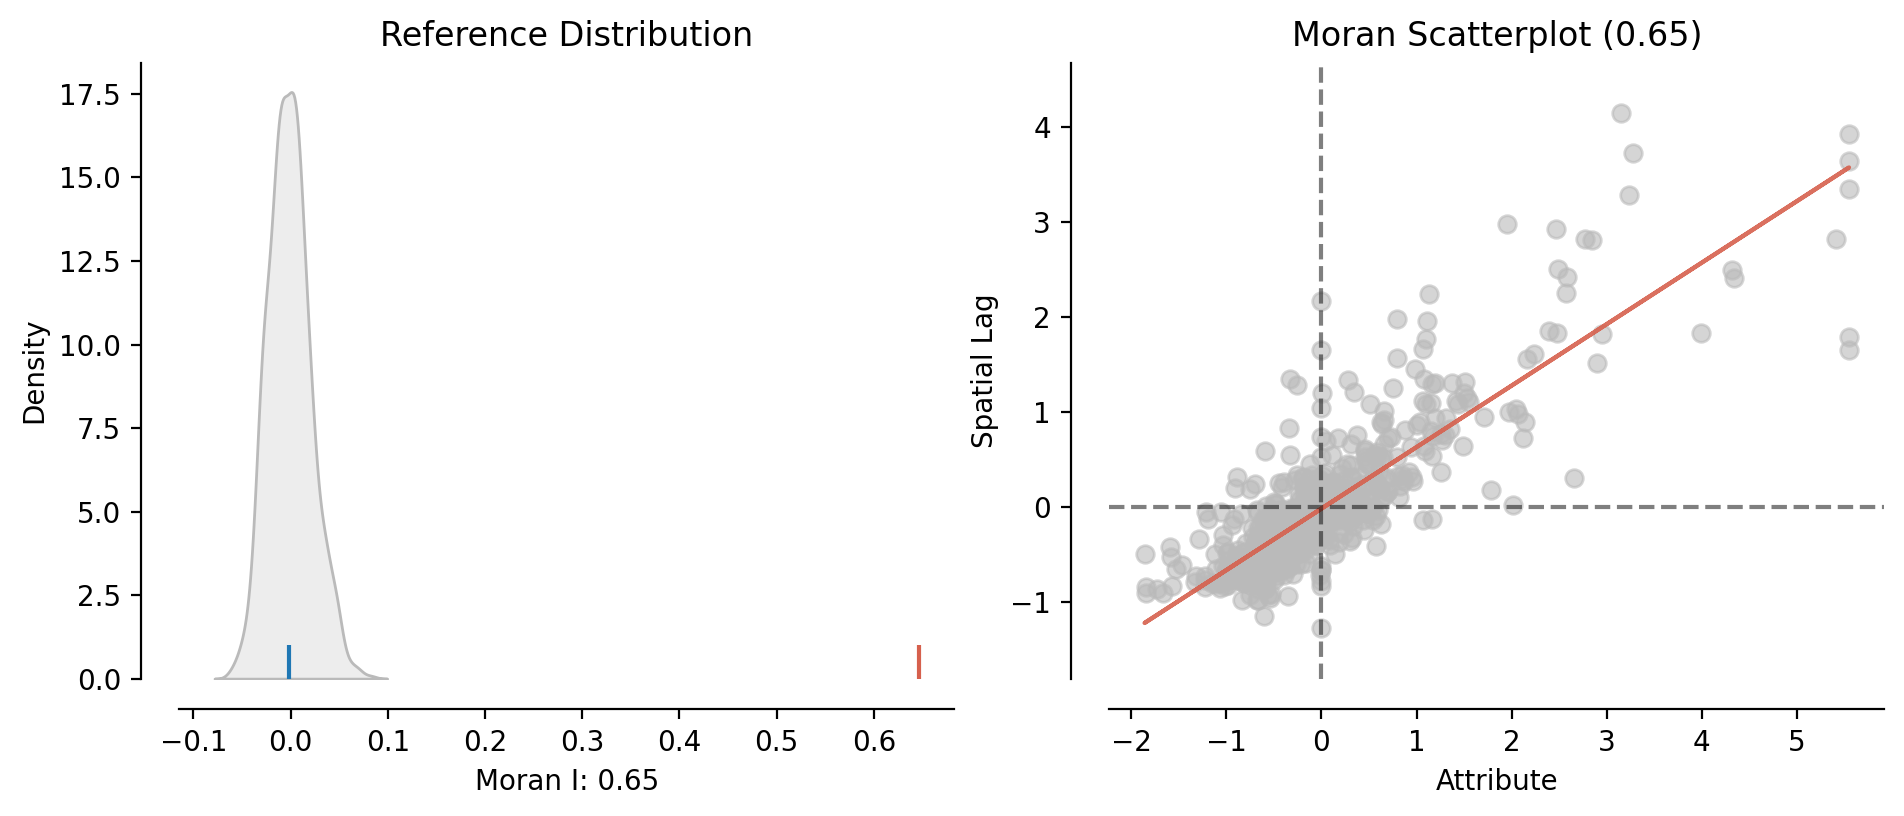

In [7]:
plot_moran(mi, zstandard=True, figsize=(11, 4))
plt.show()

Left: the observed $I$ (red line) sits far in the right tail of the reference
distribution built by permutation. Right: the **Moran scatterplot** (Anselin, 1996)
plots standardised $y$ against standardised $Wy$; its slope *is* $I$.

**Lesson —** a global statistic answers *whether* space matters, not *where*; a
significant `I` is the cue to go local (LISA), never the end of the analysis.

## 5. Local Moran's I (LISA)

LISA decomposes the global statistic into one score per tract,
$$I_i = z_i \sum_j w_{ij} z_j,\qquad z_i = (y_i - \bar y)/s,$$
so we can map *where* clustering happens. Each tract is classified by the quadrant of
the Moran scatterplot it falls in:

- **HH** / **LL** — local clusters (*hotspots* / *coldspots*),
- **HL** / **LH** — spatial outliers (*diamonds in the rough* / *holes in a donut*).

`esda.Moran_Local` uses **conditional permutations**: it holds tract $i$ fixed and
shuffles the other values among its potential neighbours, building a location-specific
null.

In [8]:
lisa = Moran_Local(y, w, permutations=999, seed=SEED)

# .Is = local statistics, .q = quadrant (1=HH, 2=LH, 3=LL, 4=HL), .p_sim = pseudo p
print("first 5 quadrants:", lisa.q[:5])
print("first 5 p_sim    :", lisa.p_sim[:5])

first 5 quadrants: [1 3 1 3 3]
first 5 p_sim    : [0.341 0.363 0.003 0.29  0.479]


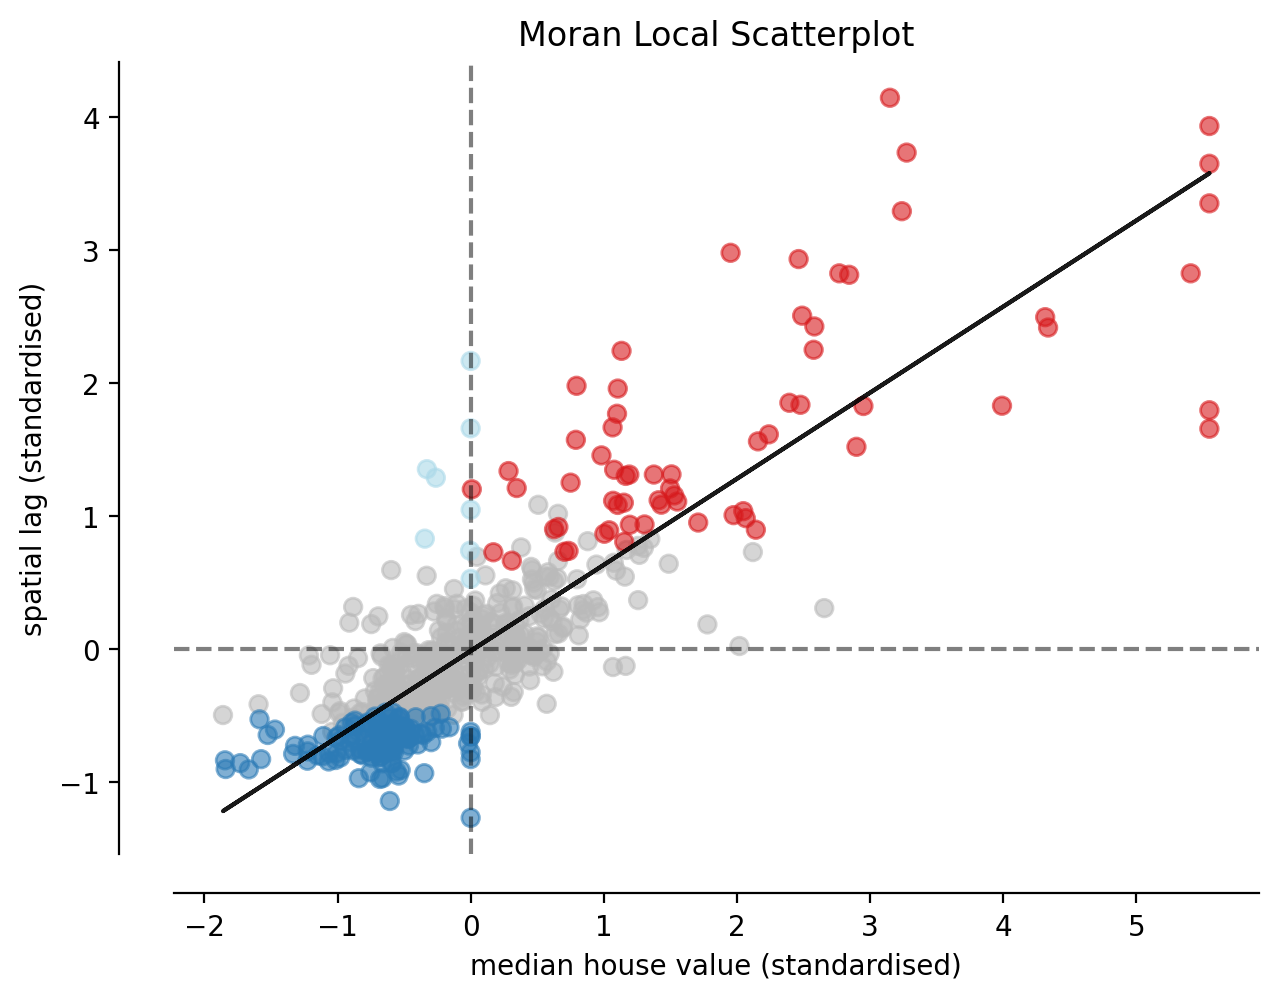

In [9]:
fig, ax = moran_scatterplot(lisa, p=0.05, aspect_equal=True)
ax.set_xlabel("median house value (standardised)")
ax.set_ylabel("spatial lag (standardised)")
plt.show()

Coloured points are the tracts a permutation test flags as unlikely by chance;
their quadrant names *what kind* of local association each shows.

## 6. Multiple testing — raw p-values vs FDR

A LISA map runs one test per tract, so with 628 tracts some "significant" hotspots
appear by chance alone. The **false discovery rate** (Benjamini–Hochberg, via
`esda.fdr`; de Castro & Singer, 2006) caps the expected *share* of flagged tracts
that are false — the gentle, standard choice for exploratory mapping.

In [10]:
raw = int((lisa.p_sim < 0.05).sum())

thr = fdr(lisa.p_sim, 0.05)          # BH-adjusted p-value cut-off
sig = lisa.p_sim <= thr
q = lisa.q

HH = int(((q == 1) & sig).sum())
LL = int(((q == 3) & sig).sum())
LH = int(((q == 2) & sig).sum())
HL = int(((q == 4) & sig).sum())

print(f"raw (p < 0.05): {raw}")
print(f"FDR-significant: {int(sig.sum())}  ->  HH={HH}  LL={LL}  LH={LH}  HL={HL}")

raw (p < 0.05): 218
FDR-significant: 84  ->  HH=34  LL=47  LH=3  HL=0


On San Diego, **218** tracts pass the raw $\alpha=0.05$ threshold, but only **84**
survive FDR (HH = 34, LL = 47): correction removed ~60% of the "significant" hotspots.

**Lesson —** never map raw LISA p-values: always report how many survived correction,
and which rule you used — permute, correct, classify, mask, report.

## 7. The LISA cluster map

The cluster map is the payoff: it names the *specific* tracts driving the global
statistic. Below, the raw map (splot default, $p<0.05$) beside the FDR-masked map —
the extra grey in the right panel is exactly the hotspots correction discarded.

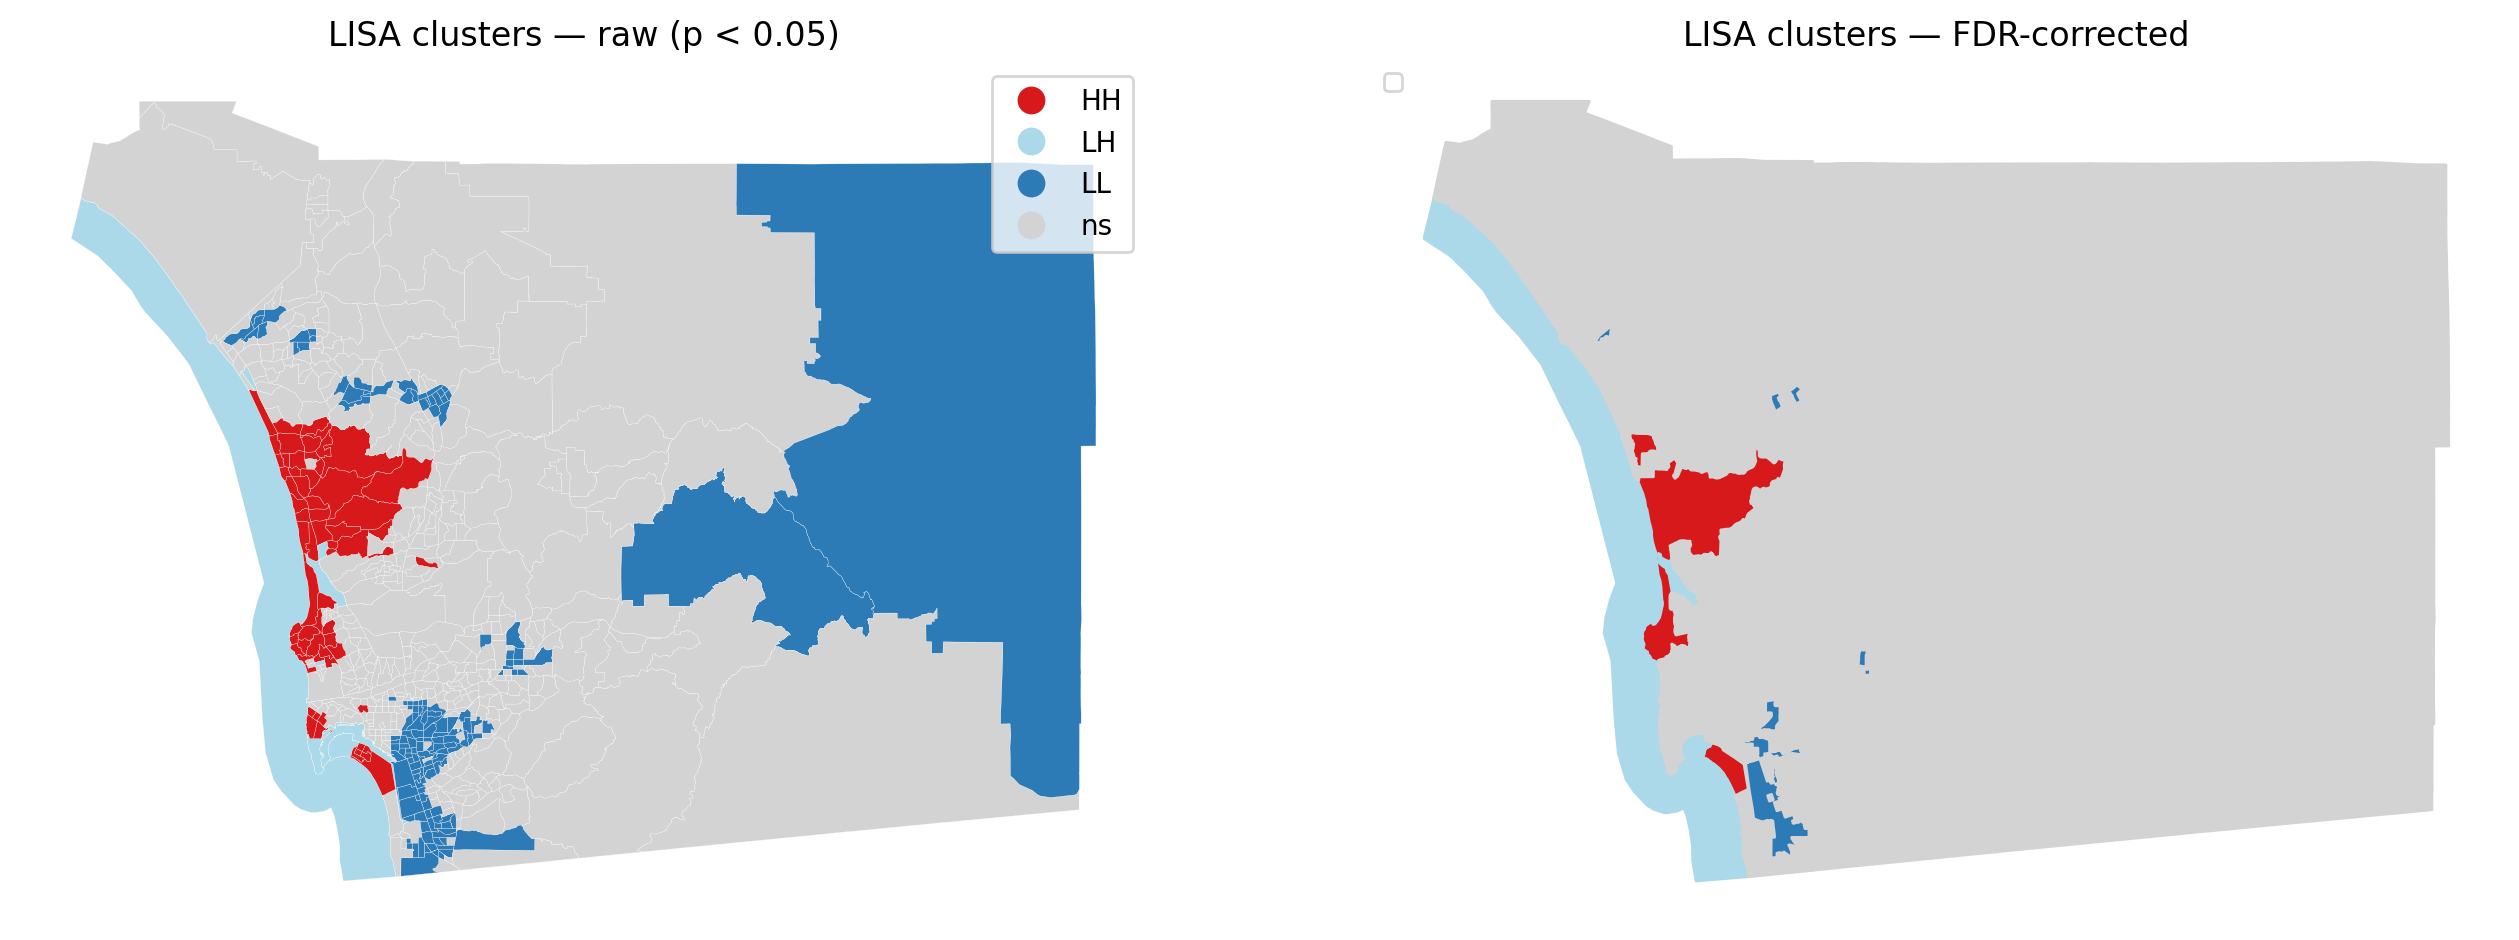

In [11]:
# FDR-masked category per tract, following the splot colour convention.
labels = np.array(["ns", "HH", "LH", "LL", "HL"])   # index by quadrant, 0 = ns
cat = np.where(sig, q, 0)
tracts["lisa_fdr"] = labels[cat]

colors = {"ns": "lightgrey", "HH": "#d7191c", "LL": "#2c7bb6",
          "LH": "#abd9e9", "HL": "#fdae61"}

f, ax = plt.subplots(1, 2, figsize=(16, 8))
lisa_cluster(lisa, tracts, p=0.05, ax=ax[0])
ax[0].set_title("LISA clusters — raw (p < 0.05)")
for name, sub in tracts.groupby("lisa_fdr"):
    sub.plot(color=colors[name], edgecolor="face", label=name, ax=ax[1])
ax[1].legend(loc="upper left", fontsize=8)
ax[1].set_title("LISA clusters — FDR-corrected")
for a in ax:
    a.set_axis_off()
plt.show()

A coastal **high–high** ribbon of expensive tracts and inland **low–low**
pockets remain after correction — an actionable geography, not just one number.

**Lesson —** a defensible LISA map is a *pipeline*, not a function call: permute,
correct, classify, mask, report — skip a step and the hotspots are not trustworthy.

> Reference: knaaptime, ["Spatial Autocorrelation"](https://knaaptime.com/urban_analysis/03_esda/spatial_autocorrelation.html);
> Anselin (1995); de Castro & Singer (2006).